In [1]:
print("Başladık")


Başladık


In [2]:
import pandas as pd
import numpy as np

In [3]:
np.random.seed(42)
n=500

In [4]:
data={
    "CustomerID": np.random.randint(1000, 1100, n),
    "OrderID": np.arange(1, n+1),
    "OrderDate": pd.date_range(start="2023-01-01", periods=n, freq="D"),
    "Sales": np.random.randint(50, 500, n),
    "Profit": np.random.randint(-20, 150, n),
    "Category": np.random.choice(["Teknoloji", "Mobilya", "Ofis Malzemeleri"],),
    "City": np.random.choice(["İstanbul", "Ankara", "İzmir"], n)
}


In [5]:
df = pd.DataFrame(data)

df.head()

,CustomerID,OrderID,OrderDate,Sales,Profit,Category,City
0,1051,1,2023-01-01,125,5,Mobilya,Ankara
1,1092,2,2023-01-02,203,26,Mobilya,İstanbul
2,1014,3,2023-01-03,193,100,Mobilya,İstanbul
3,1071,4,2023-01-04,484,35,Mobilya,Ankara
4,1060,5,2023-01-05,135,73,Mobilya,İzmir


In [6]:
df.groupby("Category")[["Sales", "Profit"]].sum().sort_values("Profit", ascending=False)

,Sales,Profit
Category,,
Mobilya,138268,31331


In [7]:
df.to_csv("data/sales.csv" , index=False)

In [8]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
profit_margin = total_profit / total_sales

total_sales, total_profit, profit_margin

(np.int64(138268), np.int64(31331), np.float64(0.2265961755431481))

In [9]:
df.groupby("Category")[["Sales", "Profit"]].sum().sort_values("Profit", ascending=False)

,Sales,Profit
Category,,
Mobilya,138268,31331


In [10]:
df.groupby("City")[["Sales", "Profit"]].sum().sort_values("Profit", ascending=False)

,Sales,Profit
City,,
İstanbul,49328,11383
Ankara,46290,10121
İzmir,42650,9827


In [11]:
# İstanbul en yüksek satış ve kârlılığa sahip ana pazardır.
# Ankara orta seviyede performans göstermektedir.
# İzmir ise hem satış hem kârlılık açısından daha düşük performans sergilemektedir.
# Bu nedenle İzmir'de pazarlama veya satış stratejileri gözden geçirilebilir.

In [12]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

monthly_sales = df.groupby(df["OrderDate"].dt.to_period("M"))["Sales"].sum()

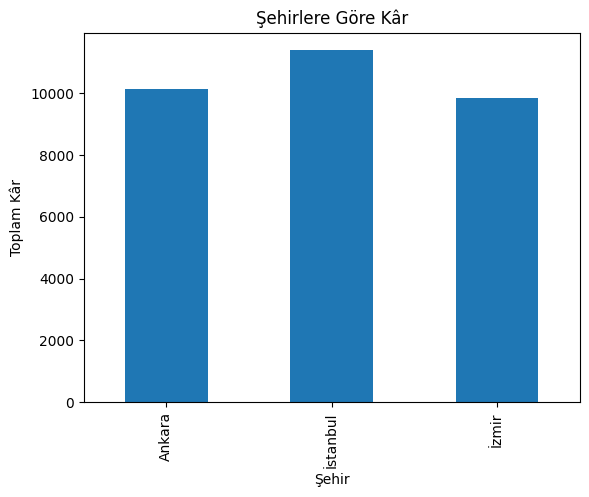

In [13]:
import matplotlib.pyplot as plt

df.groupby("City")["Profit"].sum().plot(kind="bar")
plt.title("Şehirlere Göre Kâr")
plt.xlabel("Şehir")
plt.ylabel("Toplam Kâr")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

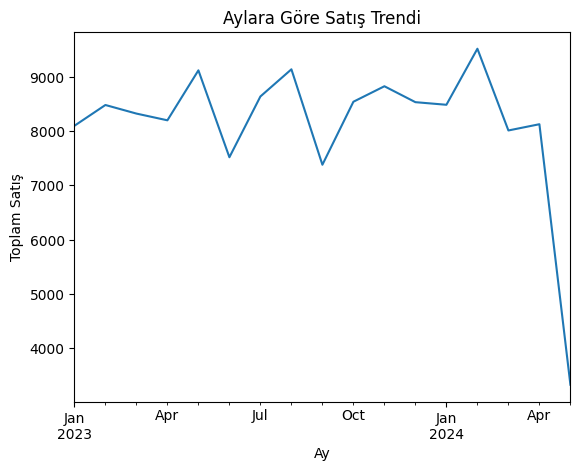

In [14]:
import matplotlib.pyplot as plt

monthly_sales.plot()
plt.title("Aylara Göre Satış Trendi")
plt.xlabel("Ay")
plt.ylabel("Toplam Satış")
plt.show

In [15]:
rfm = df.groupby("CustomerID").agg({
    "OrderDate": lambda x: (df["OrderDate"].max() - x.max()).days,
    "OrderID": "count",
    "Sales": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
1000,8,9,2580
1001,97,10,3559
1002,198,7,2214
1003,138,5,855
1004,41,3,900


In [16]:
# Her müşteri için;
# Recency-> en son ne zaman alışveriş yaptı
# Frequency-> kaç kez alışveriş yaptı
# Monetary-> ne kadar harcadı
# Yani burda müşteri davranışlarını çıkarıyoruz

In [17]:
from sklearn.preprocessing import StandardScaler


In [18]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

In [22]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4, random_state=42) 
rfm["Cluster"] = kmeans.fit_predict(rfm-rfm_scaled)
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
1000,8,9,2580,2
1001,97,10,3559,2
1002,198,7,2214,1
1003,138,5,855,0
1004,41,3,900,0


In [ ]:
# Müşterileri davranışlarına göre 4 farklı gruba ayırdı
# Her müşterinin bir segmenti var 

In [24]:
rfm.groupby("Cluster").mean()

,Recency,Frequency,Monetary
Cluster,,,
0,80.194444,4.277778,1112.305556
1,63.758621,6.586207,1909.896552
2,44.333333,10.000000,3135.111111
3,201.560000,2.600000,584.880000


In [ ]:
# Cluster 2 en değerli müşteri segmentidir.
# Bu müşteriler sık alışveriş yapmakta ve yüksek harcama gerçekleştirmektedir.

# Cluster 3 ise churn riski taşıyan müşteri grubudur.
# Uzun süredir alışveriş yapmamış ve düşük harcama yapmaktadır.

# Cluster 1 sadık müşterileri temsil etmektedir.
# Cluster 0 ise orta segment müşterilerden oluşmaktadır.

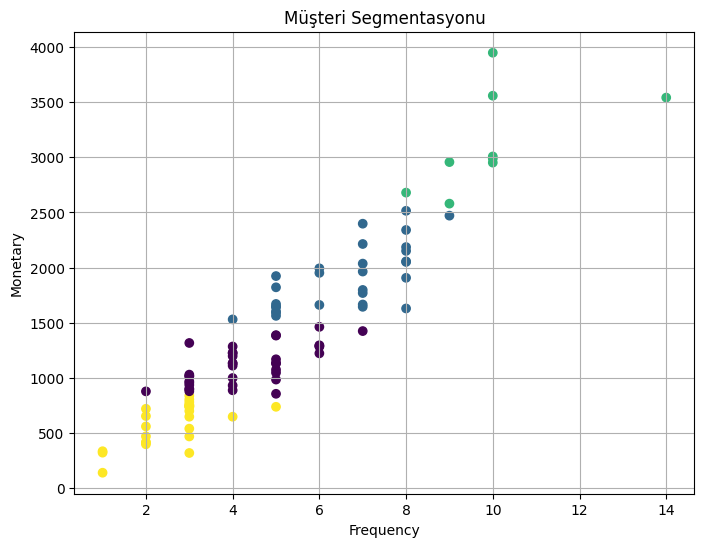

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"]

)

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Müşteri Segmentasyonu")

plt.grid(True)

plt.show()

In [ ]:
# X Ekseni: müşteri ne kadar sık alışveriş yapıyor
# Y Ekseni: ne kadar harcıyor
# Renkler: müşteri segmentleri
# Yani sağ üst ->sık alışveriş, yüksek harcama = VIP Müşteri
# Sol alt ->düşük harcama, düşük alışveriş = Riskli Müşteriler

In [29]:
churn_data = {
    "CustomerID": rfm.index,
    "Tenure": np.random.randint(1, 60, len(rfm)),
    "MonthlyCharges": np.random.randint(20, 200, len(rfm)),
    "Contract": np.random.choice(["Monthly", "Yearly"], len(rfm)),
    "Churn": np.random.choice([0, 1], len(rfm))
}

churn_df = pd.DataFrame(churn_data)

churn_df.head()

,CustomerID,Tenure,MonthlyCharges,Contract,Churn
0,1000,59,85,Yearly,0
1,1001,6,98,Yearly,1
2,1002,9,181,Yearly,1
3,1003,6,183,Yearly,0
4,1004,9,25,Monthly,1


In [ ]:
# Tenure:kaç aydır müşteri
# MonthlyCharges:aylık ödeme
# Contract:abonelik tipi
# Churn:bıraktı mı?

In [30]:
churn_df = pd.get_dummies(churn_df, drop_first=True)

churn_df.head()

,CustomerID,Tenure,MonthlyCharges,Churn,Contract_Yearly
0,1000,59,85,0,True
1,1001,6,98,1,True
2,1002,9,181,1,True
3,1003,6,183,0,True
4,1004,9,25,1,False


In [ ]:
# Yazıları anlayamayacağı için sayıya çevirdik.

In [31]:
X = churn_df.drop("Churn", axis=1)

y = churn_df["Churn"]

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [33]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [34]:
predictions = model.predict(X_test)

predictions

array([1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

In [35]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.45


In [ ]:
# Model müşteri churn davranışını belirli bir doğruluk oranıyla tahmin edebiliyor..

# Bu model sayesinde şirket churn riski taşıyan müşterileri önceden tespit ederek
# kampanya veya müşteri tutundurma stratejileri geliştirebilir.

In [ ]:
# Model doğruluk oranı düşük çıkmıştır.
# Bunun temel nedeni churn verisinin rastgele oluşturulmuş olmasıdır.

# Gerçek projelerde daha anlamlı ve ilişkili veriler kullanıldığında
# model performansı önemli ölçüde artabilir.